# Fear & Greed vs Trader Behavior Analysis

## Objective
Analyze how market sentiment affects trader performance and behavior using Hyperliquid trading data and the Fear & Greed Index.

## Data Loading

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
sentiment = pd.read_csv('fear_greed_index.csv')
hyperliquid = pd.read_csv('historical_data (1).csv')


In [5]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
hyperliquid.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# Data Cleaning and Preprocessing



Checked missing values  , no of rows and columns

In [7]:
sentiment.info()
sentiment.isnull().sum()
print( 'sentiment dataset shape:'    ,sentiment.shape)

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   timestamp       2644 non-null   int64
 1   value           2644 non-null   int64
 2   classification  2644 non-null   str  
 3   date            2644 non-null   str  
dtypes: int64(2), str(2)
memory usage: 82.8 KB
sentiment dataset shape: (2644, 4)


In [ ]:
hyperliquid.info()
print('sum of null values:' , hyperliquid.isna().sum())
print("Hyper liquid size:" , hyperliquid.shape)
hyperliquid.columns

## Duplicated Value Check
checks for duplicate rows in both datasets using pandas 'duplicated()'.
No duplicate records were found in the both datasets

In [9]:
print('duplicates in sentiment:' ,sentiment.duplicated().sum())
print('duplicates in hyperliquid:',hyperliquid.duplicated().sum())


duplicates in sentiment: 0
duplicates in hyperliquid: 0


## Converting the timestamps  and aligning it by date


In [10]:
pd.to_datetime(sentiment['timestamp'])
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
sentiment.head()





,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [11]:
hyperliquid['Timestamp IST'] = pd.to_datetime(
    hyperliquid['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

hyperliquid['date'] = hyperliquid['Timestamp IST'].dt.date
hyperliquid.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


## Merging the two datasets by Date

In [12]:
merged = pd.merge(
    hyperliquid,
    sentiment,
    on='date',
    how='inner'
)

merged = merged.sort_values('date')

merged.head()



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
83765,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1898.6,0.07220,137.08,BUY,2023-05-01 01:06:00,0.1791,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01,1682919000,63,Greed
83764,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.08240,156.39,BUY,2023-05-01 01:06:00,0.0967,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01,1682919000,63,Greed
83763,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,ETH,1897.9,0.09670,183.53,BUY,2023-05-01 01:06:00,0.0000,Open Long,0.0,0x875d3e1af52b5b758e4f04015b774e0111006a118601...,173271100,True,0.000000,0.000000e+00,1.680000e+12,2023-05-01,1682919000,63,Greed
39049,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,ETH,2230.1,0.49330,1100.11,BUY,2023-12-05 03:11:00,0.0000,Open Long,0.0,0x02721e3c6061bddfdc1204065f9dfe0138003649ef8c...,4064960965,True,0.275027,6.320000e+14,1.700000e+12,2023-12-05,1701754200,75,Extreme Greed
39057,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,BTC,41866.0,0.58211,24370.62,SELL,2023-12-05 03:11:00,-0.0150,Open Short,0.0,0xd2e598f2a6ca3f77dc7b04065f9e8a0139006b7925f4...,4064974623,True,6.092654,2.830000e+14,1.700000e+12,2023-12-05,1701754200,75,Extreme Greed


## Creating key metrics
Daily Pnl per account

In [13]:
daily_pnl_per_account = (
    merged.groupby(['Account', 'date'])['Closed PnL']
    .sum()
    .reset_index(name='daily_pnl')
)

daily_pnl_per_account.head()


,Account,date,daily_pnl
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


## average trade size
necessary for telling risk taking behaviour

In [14]:
avg_trade_size = (
    merged.groupby('date')['Size USD']
    .mean()
    .reset_index(name='avg_trade_size')
)
avg_trade_size.head()

,date,avg_trade_size
0,2023-05-01,159.000000
1,2023-12-05,5556.203333
2,2023-12-14,10291.213636
3,2023-12-15,5304.975000
4,2023-12-16,5116.256667


## WIN RATE

Win Rate measures the percentage of trades that resulted in a profit. A trade is considered a win if its `Closed PnL` is greater than zero.

The metric was created by assigning:
- `1` to profitable trades (`Closed PnL > 0`)
- `0` to non-profitable trades (`Closed PnL ≤ 0`)

The daily win rate is then calculated as the average of these values multiplied by 100.

Win Rate was used to evaluate trader performance across different market sentiment regimes and to determine whether traders were more successful during Fear, Neutral, or Greed market conditions.


In [15]:
merged['win'] = (merged['Closed PnL'] > 0).astype(int)

win_rate = (
    merged.groupby('date')['win']
    .mean()
    .mul(100)
    .reset_index(name='win_rate')
)

win_rate.head()

,date,win_rate
0,2023-05-01,0.000000
1,2023-12-05,0.000000
2,2023-12-14,36.363636
3,2023-12-15,0.000000
4,2023-12-16,0.000000


### Buy/Sell Ratio

The Buy/Sell Ratio measures trader positioning by comparing the number of Buy trades to the number of Sell trades on a given day.

A ratio greater than 1 indicates a bullish bias (more buying activity), while a ratio below 1 indicates a bearish bias (more selling activity).

This metric was created to analyze whether trader behavior changes across different Fear & Greed market sentiment conditions.

In [16]:
buy_sell_ratio = (
    merged.groupby(['date', 'Direction'])
    .size()
    .unstack(fill_value=0)
)

buy_sell_ratio['ratio'] = (
    buy_sell_ratio['Buy']
    /
    (buy_sell_ratio['Sell'] + 1)
)
buy_sell_ratio.tail()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,ratio
date,,,,,,,,,,,,,
2025-04-27,0,121,119,36,0,0,52,1,8,0,0,0,13.444444
2025-04-28,0,147,523,160,0,0,345,165,39,0,0,0,3.675000
2025-04-29,0,121,474,465,0,0,519,569,95,0,0,0,1.260417
2025-04-30,0,235,31,91,0,0,511,38,206,0,1,0,1.135266
2025-05-01,0,356,248,233,0,2,96,104,190,0,1,0,1.863874


### Average PnL by Sentiment

Average Closed PnL was calculated for each Fear & Greed sentiment category to evaluate whether trader profitability differs across market conditions.

This metric helps determine whether optimistic or pessimistic market sentiment is associated with higher trading profits.

In [17]:
sentiment_pnl = (
    merged.groupby('classification')['Closed PnL']
    .mean()
)
sentiment_pnl

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

### Fear & Greed Momentum

The daily change in the Fear & Greed Index was calculated to measure shifts in market sentiment over time.

Positive values indicate improving market sentiment, while negative values indicate worsening sentiment. This feature can help identify whether sudden sentiment changes influence trader behavior and performance.

In [20]:
sentiment = sentiment.sort_values('date')

sentiment['fg_change'] = (
    sentiment['value'].diff()
)
sentiment.head()

,timestamp,value,classification,date,fg_change
0,1517463000,30,Fear,2018-02-01,NaN
1,1517549400,15,Extreme Fear,2018-02-02,-15.0
2,1517635800,40,Fear,2018-02-03,25.0
3,1517722200,24,Extreme Fear,2018-02-04,-16.0
4,1517808600,11,Extreme Fear,2018-02-05,-13.0


### Trader Activity by Sentiment

Trader activity was analyzed across sentiment categories using:

- Number of unique accounts
- Total trading volume (Size USD)
- Average Closed PnL

These metrics help determine whether market sentiment influences trader participation, trading intensity, and profitability.

In [21]:
activity_by_sentiment = (
    merged.groupby('classification')
    .agg({
        'Account':'nunique',
        'Size USD':'sum',
        'Closed PnL':'mean'
    })
)
activity_by_sentiment

,Account,Size USD,Closed PnL
classification,,,
Extreme Fear,32,1.144843e+08,34.537862
Extreme Greed,30,1.244652e+08,67.892861
Fear,32,4.833248e+08,54.290400
Greed,31,2.885825e+08,42.743559
Neutral,31,1.802421e+08,34.307718


### Observation

Win rates varied across sentiment regimes, with Extreme Greed exhibiting the highest success rate and Extreme Fear showing the lowest. This suggests that traders tend to achieve profitable outcomes more frequently during optimistic market conditions.

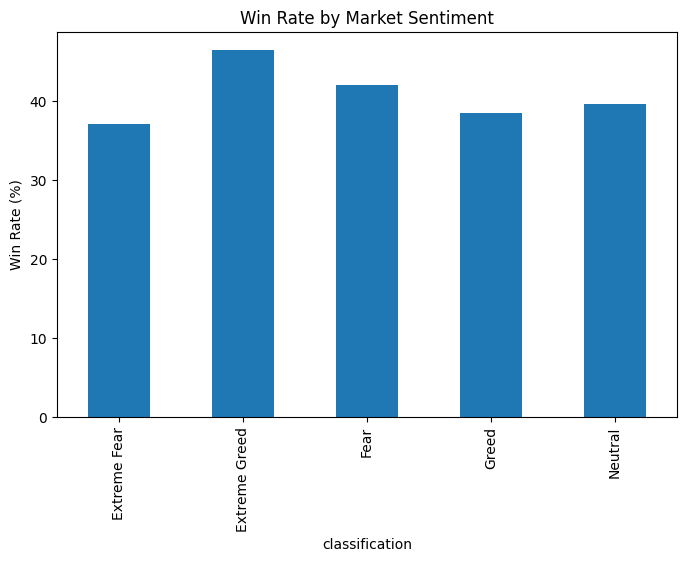

In [23]:
win_rate_sentiment = (
    merged.groupby('classification')['win']
    .mean() * 100
)

win_rate_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Win Rate (%)')
plt.title('Win Rate by Market Sentiment')
plt.show()

### Observation

Average profitability varied across sentiment regimes, with Extreme Greed producing the highest average PnL and Neutral/Extreme Fear conditions generating lower average returns. This suggests that stronger market optimism is associated with improved trading performance.

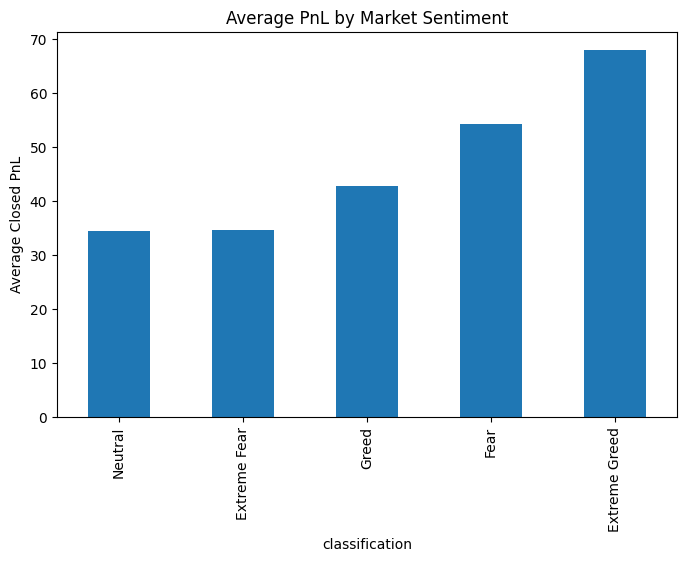

In [24]:
sentiment_pnl = (
    merged.groupby('classification')['Closed PnL']
    .mean()
    .sort_values()
)

sentiment_pnl.plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel('Average Closed PnL')
plt.title('Average PnL by Market Sentiment')
plt.show()


### Frequent vs Infrequent Trader Segmentation

To analyze whether trading activity influences performance, traders were segmented based on their total number of executed trades.

The number of trades performed by each account was calculated, and the 75th percentile of trade counts was used as a threshold. Traders whose activity exceeded this threshold were classified as **Frequent Traders**, while the remaining traders were classified as **Infrequent Traders**.

This segmentation was used to compare trading behavior, profitability, and win rates between highly active traders and less active participants.

In [25]:
account_activity = (
    merged.groupby('Account')
    .size()
    .reset_index(name='trade_count')
)

threshold = account_activity['trade_count'].quantile(0.75)

frequent_accounts = account_activity[
    account_activity['trade_count'] >= threshold
]['Account']

merged['trader_segment'] = merged['Account'].apply(
    lambda x: 'Frequent'
    if x in frequent_accounts.values
    else 'Infrequent'
)

### Observation

Frequent traders achieved a higher win rate (42.3%) than infrequent traders (38.6%), indicating that they were successful more often. However, infrequent traders generated higher average PnL despite having a lower win rate, suggesting that their profitable trades tended to be larger. Infrequent traders also maintained larger average position sizes, reflecting a more aggressive trading approach.

In [26]:
segment_analysis = (
    merged.groupby('trader_segment')
    .agg(
        avg_pnl=('Closed PnL', 'mean'),
        win_rate=('win', 'mean'),
        avg_position_size=('Size USD', 'mean'),
        trades=('Account', 'count')
    )
)

segment_analysis['win_rate'] *= 100

print(segment_analysis)

                  avg_pnl   win_rate  avg_position_size  trades
trader_segment                                                 
Frequent        38.141072  42.333558        4813.325078  142152
Infrequent      69.971583  38.636956        7338.994399   69066


## Defining Consistent winners as traders with win rate over 50%


In [27]:
account_stats = (
    merged.groupby('Account')
    .agg(
        win_rate=('win', 'mean'),
        avg_pnl=('Closed PnL', 'mean'),
        trades=('Account', 'count')
    )
)

account_stats['win_rate'] *= 100

In [28]:
account_stats['segment'] = account_stats['win_rate'].apply(
    lambda x: 'Consistent Winner' if x >= 50 else 'Inconsistent Trader'
)

account_stats.head()

,win_rate,avg_pnl,trades,segment
Account,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236,419.127768,3818,Inconsistent Trader
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978,6.577654,7280,Inconsistent Trader
0x271b280974205ca63b716753467d5a371de622ab,30.191651,-18.492043,3809,Inconsistent Trader
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463,9.951530,13311,Inconsistent Trader
0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355,52.071011,3239,Consistent Winner


### Observation

Consistent winners achieved a substantially higher average win rate (63.5%) compared to inconsistent traders (37.9%). However, inconsistent traders generated a slightly higher average PnL despite their lower success rate. This suggests that a lower win rate can still be profitable when winning trades are significantly larger than losing trades.

In [29]:
segment_summary = (
    account_stats.groupby('segment')
    .agg(
        avg_win_rate=('win_rate', 'mean'),
        avg_pnl=('avg_pnl', 'mean'),
        trader_count=('trades', 'count')
    )
)

print(segment_summary)

                     avg_win_rate    avg_pnl  trader_count
segment                                                   
Consistent Winner       63.464381  88.360793             3
Inconsistent Trader     37.900509  97.663474            29


### Observation

Only 3 out of 32 traders were classified as Consistent Winners, while the remaining 29 traders fell into the Inconsistent Trader category, indicating that sustained trading success was achieved by a small minority of participants.

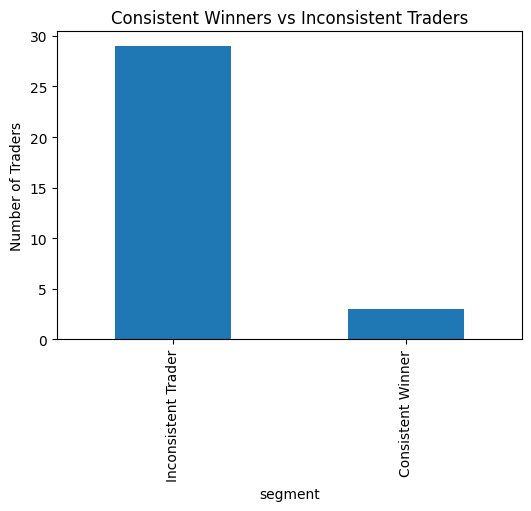

In [30]:


account_stats['segment'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Consistent Winners vs Inconsistent Traders')
plt.ylabel('Number of Traders')
plt.show()

### Observation

Inconsistent Traders achieved a slightly higher average PnL than Consistent Winners despite having a lower win rate. This suggests that larger winning trades may compensate for a lower percentage of successful trades.

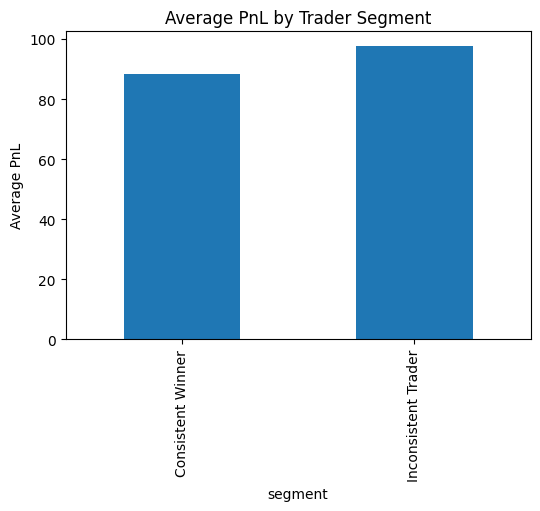

In [31]:
segment_summary['avg_pnl'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average PnL by Trader Segment')
plt.ylabel('Average PnL')
plt.show()

### Observation

Consistent Winners achieved a substantially higher average win rate (63.5%) compared to Inconsistent Traders (37.9%), indicating that they were successful on a much larger proportion of their trades.

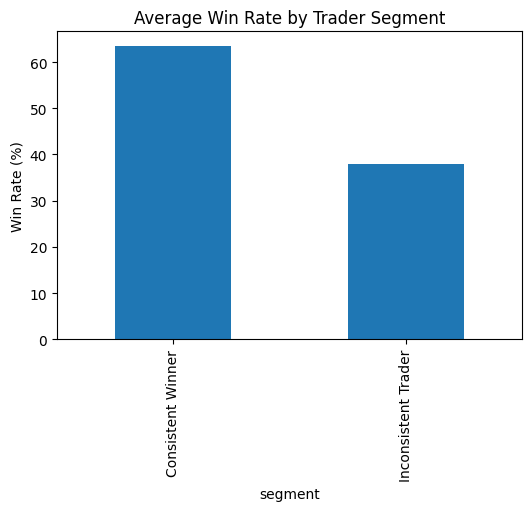

In [32]:
segment_summary['avg_win_rate'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Average Win Rate by Trader Segment')
plt.ylabel('Win Rate (%)')
plt.show()

### Buy/Sell Ratio by Market Sentiment

The daily Buy/Sell Ratio was merged with the Fear & Greed Index to examine whether trader positioning changes under different market sentiment conditions.

A Buy/Sell Ratio greater than 1 indicates a

In [33]:
buy_sell_ratio = buy_sell_ratio.reset_index()

buy_sell_sentiment = buy_sell_ratio.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='left'
)

buy_sell_sentiment.head()

,date,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,ratio,classification,value
0,2023-05-01,0,0,0,0,0,0,3,0,0,0,0,0,0.0,Greed,63
1,2023-12-05,0,0,0,0,0,0,7,2,0,0,0,0,0.0,Extreme Greed,75
2,2023-12-14,0,0,4,2,0,0,3,2,0,0,0,0,0.0,Greed,72
3,2023-12-15,0,0,0,2,0,0,0,0,0,0,0,0,0.0,Greed,70
4,2023-12-16,0,0,0,0,0,0,3,0,0,0,0,0,0.0,Greed,67


### Buy/Sell Ratio by Market Sentiment

The average Buy/Sell Ratio was calculated for each sentiment category to analyze whether trader positioning changes under different market conditions.

A higher ratio indicates a stronger buying bias, while a lower ratio indicates a stronger selling bias. Comparing this metric across sentiment regimes helps identify whether traders become more bullish during Greed periods or more cautious during Fear periods.

### Observation

The Buy/Sell Ratio remained above 1 across all sentiment categories, indicating an overall buying bias among traders. Surprisingly, the highest Buy/Sell Ratio was observed during Fear periods (4.77), while Extreme Greed exhibited the lowest ratio (1.19). This suggests that traders may have adopted a contrarian approach by increasing buying activity during fearful market conditions rather than chasing bullish sentiment.

In [34]:
buy_sell_by_sentiment = (
    buy_sell_sentiment
    .groupby('classification')['ratio']
    .mean()
)

print(buy_sell_by_sentiment)

classification
Extreme Fear     2.394566
Extreme Greed    1.194009
Fear             4.767353
Greed            2.263881
Neutral          3.667791
Name: ratio, dtype: float64


### Observation

Traders maintained a net buying bias across all sentiment regimes, with the strongest buying activity occurring during Fear periods and the weakest during Extreme Greed periods.

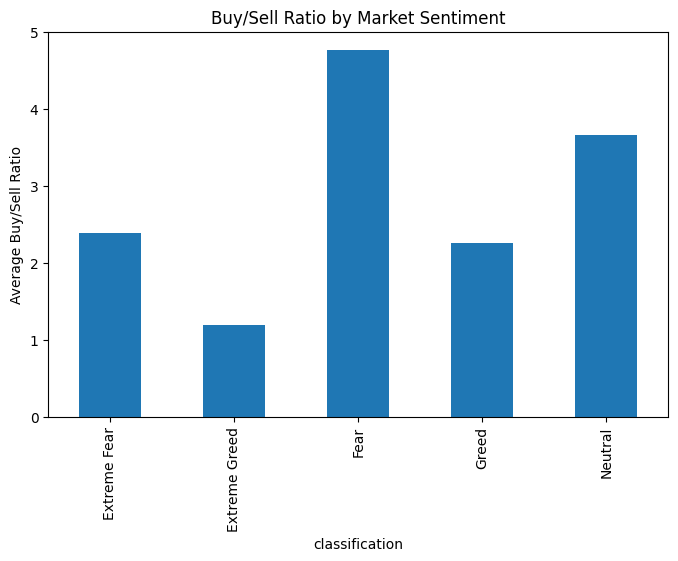

In [35]:
buy_sell_by_sentiment.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Buy/Sell Ratio by Market Sentiment')
plt.ylabel('Average Buy/Sell Ratio')
plt.show()

### Strategy 1: Increase Selectivity During Fear, Expand Opportunities During Greed

Since traders achieved the highest average PnL and win rates during Greed and Extreme Greed periods, traders may consider taking a larger number of high-conviction trades during optimistic market conditions. During Fear periods, trade selection should be more selective despite higher market activity, as increased participation does not necessarily translate into higher profitability.

### Strategy 2: Focus on Trade Quality Rather Than Trade Quantity

Frequent traders achieved higher win rates, while infrequent traders generated higher average profits per trade. This suggests that executing more trades can improve consistency, but larger profits may come from carefully selected opportunities. Traders should prioritize trade quality and position sizing rather than simply increasing trading frequency.